**Machine learning Python**

In [1]:
import sklearn

In [2]:
import pandas as pd
import numpy as np
# Lecture des données
## Charger les données ou les lire directement en précisant le chemin
path="../divers/"
data=pd.read_csv(path+"healthcare_synthetic_data.csv",sep=",",header=0)
# Vérification du contenu
data.head()

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
0,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
1,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
2,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
3,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
4,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0


In [3]:
data=data.drop('Patient_ID',axis=1)

In [4]:
data["Gender"]=pd.Categorical(data["Gender"],ordered=False)
data["Smoking_Status"]=pd.Categorical(data["Smoking_Status"],ordered=False)
data["Alcohol_Consumption"]=pd.Categorical(data["Alcohol_Consumption"],ordered=False)
data["Physical_Activity_Level"]=pd.Categorical(data["Physical_Activity_Level"],ordered=True)
data["Family_History"]=pd.Categorical(data["Family_History"],ordered=False)
data["Heart_Disease_Risk"]=pd.Categorical(data["Heart_Disease_Risk"],ordered=False)


In [5]:
data.describe()

,Age,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Stress_Level,Sleep_Hours
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,54.538133,165.336767,75.252573,27.446080,135.117667,90.541267,216.248000,140.355267,43.307867,99.670200,5.503667,6.506067
std,11.875294,9.186313,14.110559,4.134953,11.260634,8.443095,22.692222,17.914089,5.963153,15.261355,2.874277,1.212626
min,25.000000,138.500000,33.700000,14.500000,90.000000,60.000000,127.000000,70.000000,20.000000,60.000000,1.000000,4.000000
25%,46.000000,158.500000,65.200000,24.500000,127.000000,85.000000,201.000000,128.000000,39.000000,89.000000,3.000000,6.000000
50%,55.000000,164.700000,73.900000,27.200000,135.000000,91.000000,216.000000,140.000000,43.000000,99.000000,5.500000,7.000000
75%,63.000000,172.000000,83.900000,30.000000,143.000000,96.000000,231.000000,152.000000,47.000000,110.000000,8.000000,7.000000
max,85.000000,198.100000,150.100000,46.100000,182.000000,120.000000,303.000000,210.000000,68.000000,167.000000,10.000000,10.000000


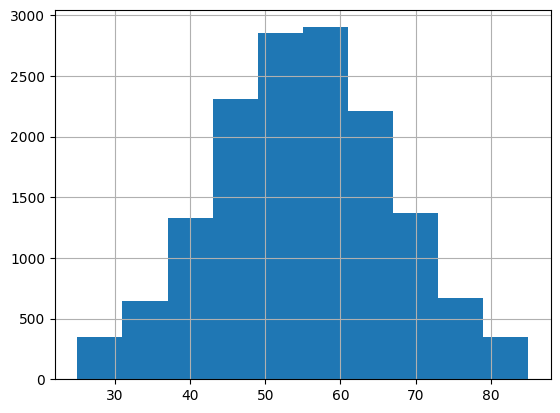

In [6]:
import matplotlib.pyplot as plt
data["Age"].hist()
plt.show()

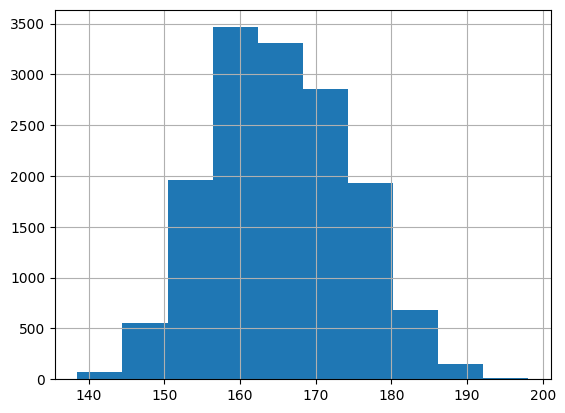

In [7]:
data["Height_cm"].hist()
plt.show()

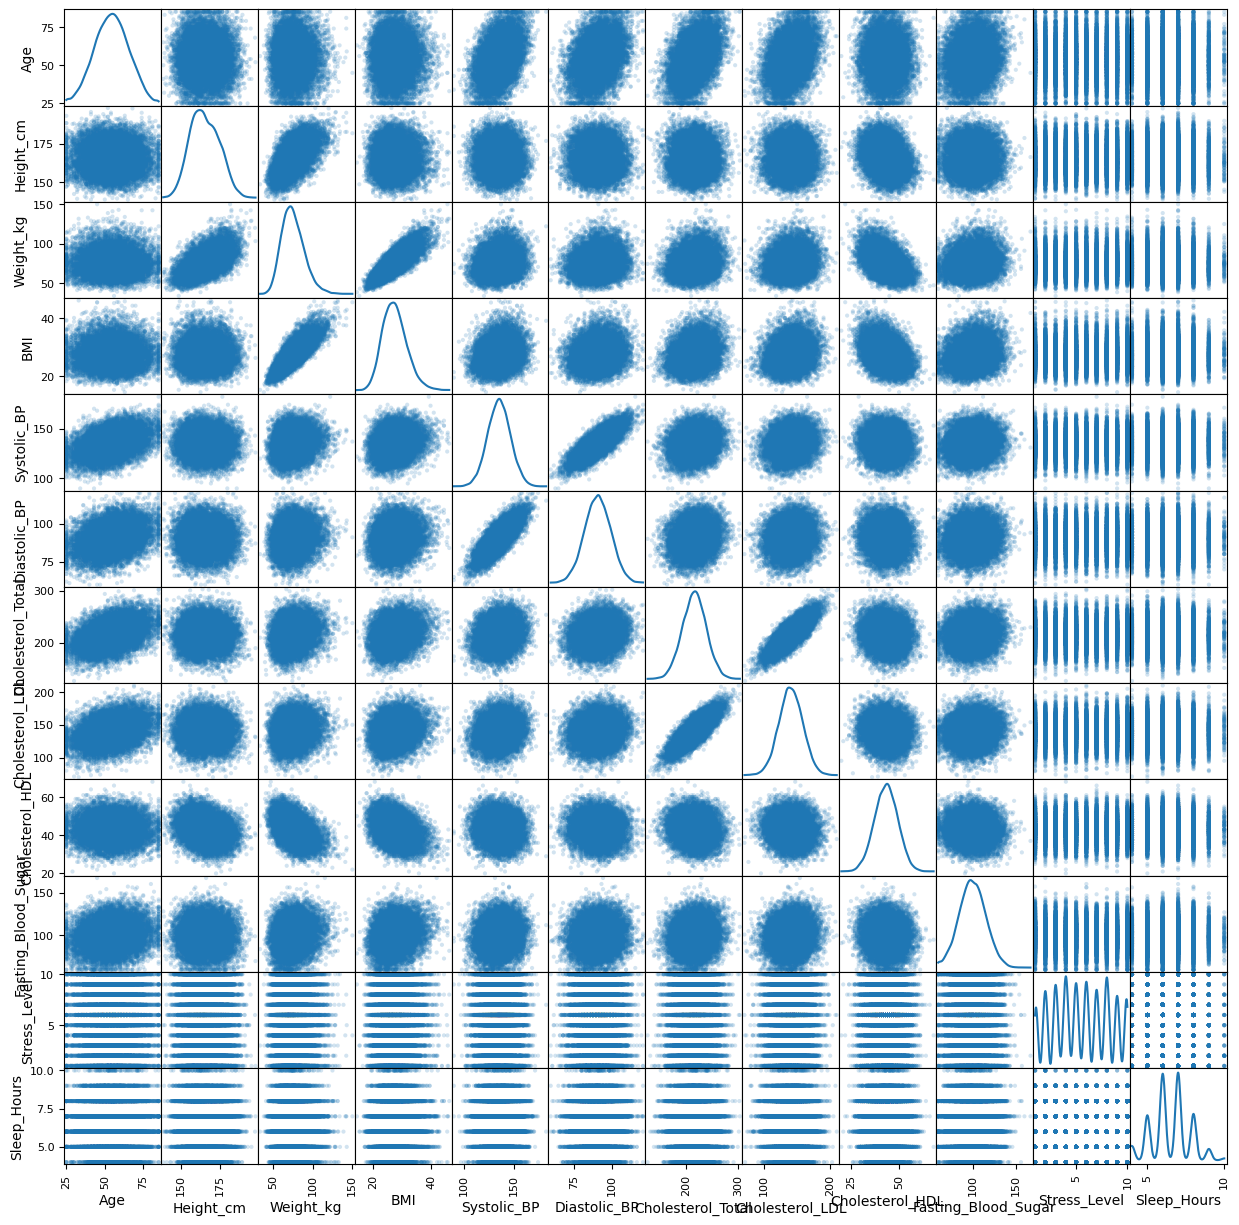

In [8]:
from pandas.plotting import scatter_matrix
scatter_matrix(data[["Age","Height_cm","Weight_kg","BMI","Systolic_BP","Diastolic_BP","Cholesterol_Total","Cholesterol_LDL","Cholesterol_HDL","Fasting_Blood_Sugar","Stress_Level","Sleep_Hours"]], alpha=0.2, 
               figsize=(15, 15), diagonal='kde')
plt.show()

In [9]:
# Variables explicatives
dataDum=pd.get_dummies(data[["Gender","Smoking_Status","Alcohol_Consumption","Physical_Activity_Level","Family_History"]])
dataDum.head()

,Gender_0,Gender_1,Smoking_Status_0,Smoking_Status_1,Alcohol_Consumption_0,Alcohol_Consumption_1,Alcohol_Consumption_2,Physical_Activity_Level_0,Physical_Activity_Level_1,Physical_Activity_Level_2,Physical_Activity_Level_3,Family_History_0,Family_History_1
0,True,False,True,False,False,True,False,False,False,False,True,True,False
1,True,False,True,False,True,False,False,False,True,False,False,True,False
2,False,True,True,False,True,False,False,True,False,False,False,True,False
3,False,True,True,False,True,False,False,False,True,False,False,True,False
4,False,True,True,False,False,True,False,False,False,True,False,True,False


In [10]:
del dataDum["Gender_0"]
del dataDum["Smoking_Status_0"]
del dataDum["Family_History_0"]

In [11]:
dataQuant=data[["Age","Height_cm","Weight_kg","BMI","Systolic_BP","Diastolic_BP","Cholesterol_Total","Cholesterol_LDL","Cholesterol_HDL","Fasting_Blood_Sugar","Stress_Level","Sleep_Hours"]]
dataC=pd.concat([dataDum,dataQuant],axis=1)
dataC.head()

,Gender_1,Smoking_Status_1,Alcohol_Consumption_0,Alcohol_Consumption_1,Alcohol_Consumption_2,Physical_Activity_Level_0,Physical_Activity_Level_1,Physical_Activity_Level_2,Physical_Activity_Level_3,Family_History_1,...,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Stress_Level,Sleep_Hours
0,False,False,False,True,False,False,False,False,True,False,...,51.3,23.8,140,89,217,151,52,83,1,8
1,False,False,True,False,False,False,True,False,False,False,...,76.6,29.3,128,81,203,119,38,116,7,9
2,True,False,True,False,False,True,False,False,False,False,...,92.4,30.3,141,100,173,124,45,90,1,7
3,True,False,True,False,False,False,True,False,False,False,...,68.9,22.9,136,96,193,117,45,81,2,7
4,True,False,False,True,False,False,False,True,False,False,...,79.8,25.0,122,80,236,153,41,79,2,6


In [12]:
# variable à expliquer binaire (risque d'AVC)
Yb=data["Heart_Disease_Risk"]
# variable à expliquer quantitative (cholestérol)
Yr=data["Cholesterol_LDL"]

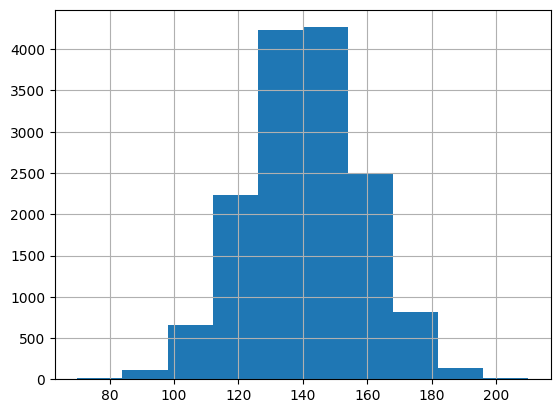

In [13]:
Yr.hist()
plt.show()

Séparation des deux échantillons (train et test)

In [14]:
from sklearn.model_selection import train_test_split  
X_train,X_test,Y_train_AVC,Y_test_AVC=train_test_split(dataC,Yb,test_size=3000,random_state=11)
X_train,X_test,Y_train_cholest,Y_test_cholest=train_test_split(dataC,Yr,test_size=3000,random_state=11)

In [15]:
from sklearn.preprocessing import StandardScaler  
# L'algorithme des réseaux de neurones nécessite éventuellement une normalisation 
# des variables explicatives avec les commandes ci-dessous
scaler = StandardScaler()  
scaler.fit(X_train)
Xr_train = scaler.transform(X_train)  
# Meme transformation sur le test
Xr_test = scaler.transform(X_test)

Partie régression linéaire et logistique


Première partie : logit pour AVC

D'abord modèle linéaire de base, sans sélection et sans pénalisation

In [27]:
from sklearn import linear_model
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

In [37]:
logit_simple= linear_model.LogisticRegression()
logit_simple.fit(Xr_train,Y_train_AVC)
y_pred=logit_simple.predict(Xr_test)
print("MSE=",mean_squared_error(Y_test_AVC,prev))

MSE= 0.268


In [38]:
from sklearn.metrics import accuracy_score, classification_report
print(f"Accuracy : {accuracy_score(Y_test_AVC, y_pred):.3f}")


Accuracy : 0.732


In [40]:

# matrice de confusion
table=pd.crosstab(y_pred,Y_test_AVC)
print(table)

Heart_Disease_Risk     0    1
row_0                        
0                   1362  496
1                    308  834


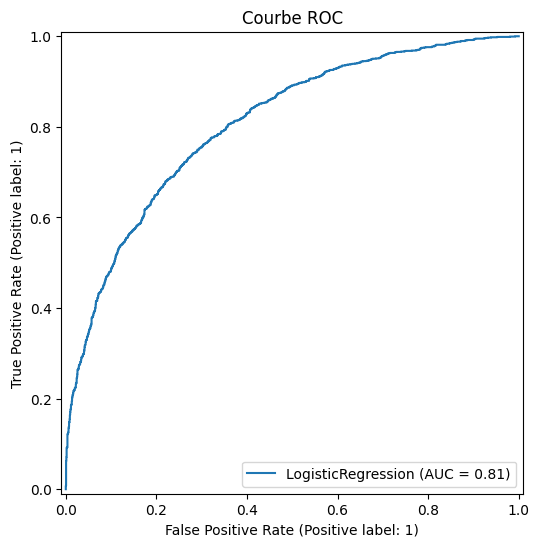

In [43]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(logit_simple, Xr_test, Y_test_AVC)
plt.title("Courbe ROC")
plt.show()

On commence par déterminer le meilleur paramètre de pénalisation LASSO

In [17]:
# Optimisation du paramètre de pénalisation
# grille de valeurs
param=[{"C":[1,1.2,1.5,1.7,2,3,4]}]
logit = GridSearchCV(LogisticRegression(penalty="l1",solver="liblinear"), param,cv=5,n_jobs=-1)
logitOpt=logit.fit(Xr_train, Y_train_AVC)  # GridSearchCV est lui-même un estimateur
# paramètre optimal
logitOpt.best_params_["C"]
print("Meilleur score = %f, Meilleur paramètre = %s" % (1.-logitOpt.best_score_,logitOpt.best_params_))

/home/brandam/Bureau/4A/ML/ML-project/.venv-1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/brandam/Bureau/4A/ML/ML-project/.venv-1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/brandam/Bureau/4A/ML/ML-project/.venv-1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent v

Meilleur score = 0.260250, Meilleur paramètre = {'C': 1}


/home/brandam/Bureau/4A/ML/ML-project/.venv-1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/brandam/Bureau/4A/ML/ML-project/.venv-1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [18]:
# erreur sur l'échantillon de test
1-logitOpt.score(Xr_test, Y_test_AVC)

0.268

In [19]:
# Prévision
y_chap = logitOpt.predict(Xr_test)
# matrice de confusion
table=pd.crosstab(y_chap,Y_test_AVC)
print(table)

Heart_Disease_Risk     0    1
row_0                        
0                   1360  494
1                    310  836


Coefficients de la régression logistique avec LASSO

In [20]:
# Coefficients
logitLasso=LogisticRegression(penalty="l1",C=logitOpt.best_params_['C'],
                              solver="liblinear")
logitCoef=logitLasso.fit(Xr_train,Y_train_AVC).coef_
print(logitCoef[0])

[-0.04406477  0.90016061  0.03176189 -0.00336225  0.          0.25144002
  0.04162936 -0.17754112 -0.28270773  0.54590943  0.24329649  0.
  0.05533559  0.1495321   0.34289938 -0.01675852 -0.03780389  0.20877514
 -0.05218669  0.30399831  0.29611286 -0.10164015]


/home/brandam/Bureau/4A/ML/ML-project/.venv-1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/brandam/Bureau/4A/ML/ML-project/.venv-1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [21]:
coef = pd.Series(logitCoef[0], index = X_train.columns)
print("Lasso conserve " + str(sum(coef != 0)) + 
      " variables et en supprime " +  str(sum(coef == 0)))

Lasso conserve 20 variables et en supprime 2


Text(0.5, 1.0, 'Coefficients du modèle lasso')

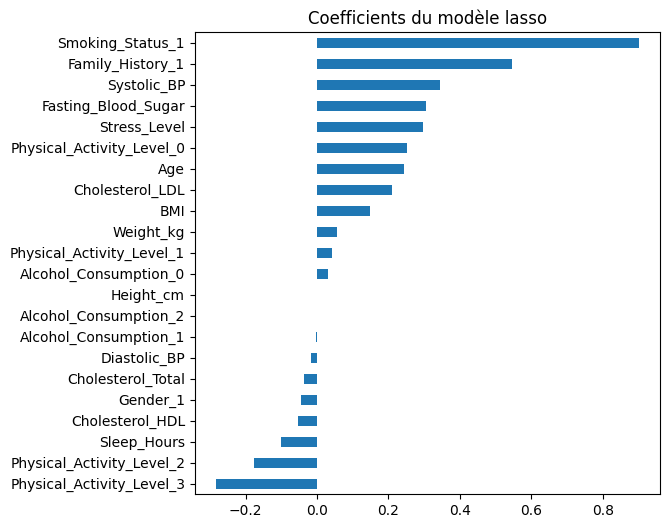

In [22]:
imp_coef = coef.sort_values()
plt.rcParams['figure.figsize'] = (6.0, 6.0)
imp_coef.plot(kind = "barh")
plt.title(u"Coefficients du modèle lasso")

Selon ce modèle, les facteurs de risque principaux sont : consommation de tabac, antécédents familiaux, systolic_BP. Au contraire, la pratique du sport ainsi que le sommeil diminuent ce risque.

/home/brandam/Bureau/4A/ML/ML-project/.venv-1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/brandam/Bureau/4A/ML/ML-project/.venv-1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


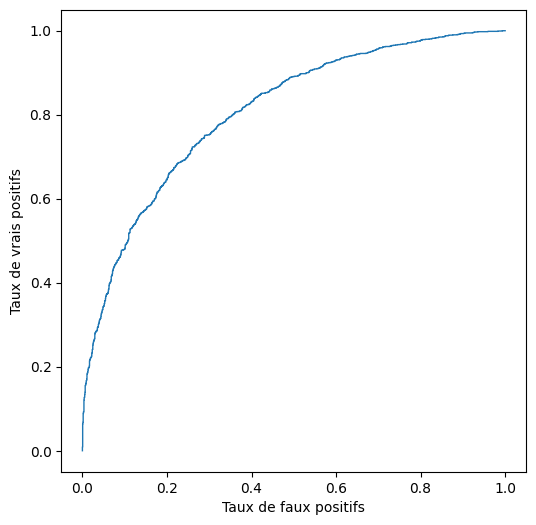

In [23]:
from sklearn.metrics import roc_curve
probas_ = LogisticRegression(penalty="l1", solver="liblinear",
                    C=logitOpt.best_params_['C']).fit(X_train, Y_train_AVC).predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(Y_test_AVC, probas_[:,1])
plt.plot(fpr, tpr, lw=1)
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.show()

Courbe ROC pas ouf.

Comparaison des 2 premières méthodes

/home/brandam/Bureau/4A/ML/ML-project/.venv-1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/brandam/Bureau/4A/ML/ML-project/.venv-1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/brandam/Bureau/4A/ML/ML-project/.venv-1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of pe

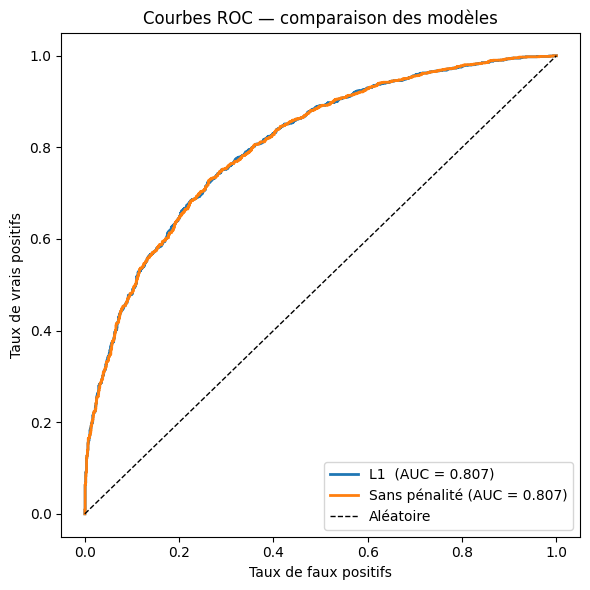

In [44]:
from sklearn.metrics import roc_curve, auc

# --- modèle L1 (votre code existant) --------------------------------
probas_l1 = LogisticRegression(
    penalty="l1", solver="liblinear",
    C=logitOpt.best_params_['C']
).fit(X_train, Y_train_AVC).predict_proba(X_test)

fpr_l1, tpr_l1, _ = roc_curve(Y_test_AVC, probas_l1[:, 1])
auc_l1 = auc(fpr_l1, tpr_l1)

# --- modèle sans pénalisation (nouveau) -----------------------------
probas_none = LogisticRegression(
    penalty=None, solver="lbfgs", max_iter=1000
).fit(X_train, Y_train_AVC).predict_proba(X_test)

fpr_none, tpr_none, _ = roc_curve(Y_test_AVC, probas_none[:, 1])
auc_none = auc(fpr_none, tpr_none)

# --- tracé conjoint -------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(fpr_l1,   tpr_l1,   lw=2, label=f"L1  (AUC = {auc_l1:.3f})")
ax.plot(fpr_none, tpr_none, lw=2, label=f"Sans pénalité (AUC = {auc_none:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Aléatoire")

ax.set_xlabel("Taux de faux positifs")
ax.set_ylabel("Taux de vrais positifs")
ax.set_title("Courbes ROC — comparaison des modèles")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

Modèle linéaire avec sélection de variable